In [1]:
from pathlib import Path

from vectormesh.data.cache import VectorCache

artefacts = Path("../artefacts")

# these globs use the `legal_bert` caches. You can change it to pick the `legal_dutch` caches.
trainpath = next(artefacts.glob("*bert*train/")) 
validpath = next(artefacts.glob("*bert*valid/"))

if not (trainpath.is_dir() and validpath.is_dir()):
    raise FileNotFoundError(f"Data folder not found")

traincache = VectorCache.load(path=trainpath)
validcache = VectorCache.load(path=validpath)

2026-06-08 09:25:51.742 | SUCCESS  | vectormesh.data.cache:load:140 - Cache loaded from ../artefacts/20260113075724_aktes_theshold_50_d97342_legal_bert_train
2026-06-08 09:25:51.748 | SUCCESS  | vectormesh.data.cache:load:140 - Cache loaded from ../artefacts/20260113080216_aktes_theshold_50_d97342_legal_bert_valid


If you have received caches from your instructor, use those:

- [`Gerwin/legal-bert-dutch-english`](https://huggingface.co/Gerwin/legal-bert-dutch-english) is the model used to train `legal_bert`
- [`joelniklaus/legal-dutch-roberta-base`](https://huggingface.co/joelniklaus/legal-dutch-roberta-base) is the model used to train `legal_dutch`

If you dont have access to this data (yet), you can test the code with the imdb example too by creating your own caches and loading them from the artefacts folder.

In [2]:
import json
def print_cache_info(cache: VectorCache):
    print(f"Cache name: {cache.name}")
    print(f"Cache directory: {cache.cache_dir}")
    print(f"Dataset: {cache.dataset}")
    print(f"Metadata: {json.dumps(cache.metadata, indent=2)}")

print_cache_info(traincache)

Cache name: 20260113075724_aktes_theshold_50_d97342_legal_bert_train
Cache directory: /Users/rgrouls/code/courses/vectormesh/artefacts
Dataset: Dataset({
    features: ['text', 'target', 'labels', 'legal_dutch'],
    num_rows: 15532
})
Metadata: {
  "legal_dutch": {
    "vectormesh_version": "0.1.0",
    "model_tag": "Gerwin/legal-bert-dutch-english",
    "vectorizer_type": "Vectorizer",
    "tensordtype": 2,
    "hidden_size": 768,
    "context_size": 512,
    "chunk_sizes": {}
  },
  "features": [
    "text",
    "target",
    "labels",
    "legal_dutch"
  ],
  "created_at": "2026-01-13T07:57:34.682329",
  "num_observations": 15532
}


Output should look something like this:

```json
Cache name: 20260113075724_aktes_theshold_50_d97342_legal_bert_train
Cache directory: /path/to/vectormesh/assets
Dataset: Dataset({
    features: ['text', 'target', 'labels', 'legal_dutch'],
    num_rows: 15532
})
Metadata: {
  "legal_dutch": {
    "vectormesh_version": "0.1.0",
    "model_tag": "Gerwin/legal-bert-dutch-english",
    "vectorizer_type": "Vectorizer",
    "tensordtype": 2,
    "hidden_size": 768,
    "context_size": 512,
    "chunk_sizes": {}
  },
  "features": [
    "text",
    "target",
    "labels",
    "legal_dutch"
  ],
  "created_at": "2026-01-13T07:57:34.682329",
  "num_observations": 15532
}
```

In [3]:
print_cache_info(validcache)

Cache name: 20260113080216_aktes_theshold_50_d97342_legal_bert_valid
Cache directory: /Users/rgrouls/code/courses/vectormesh/artefacts
Dataset: Dataset({
    features: ['text', 'target', 'labels', 'legal_dutch'],
    num_rows: 1942
})
Metadata: {
  "legal_dutch": {
    "vectormesh_version": "0.1.0",
    "model_tag": "Gerwin/legal-bert-dutch-english",
    "vectorizer_type": "Vectorizer",
    "tensordtype": 2,
    "hidden_size": 768,
    "context_size": 512,
    "chunk_sizes": {
      "8": 113,
      "13": 90,
      "4": 68,
      "19": 39,
      "10": 179,
      "15": 94,
      "11": 153,
      "14": 88,
      "9": 156,
      "3": 119,
      "27": 14,
      "2": 91,
      "12": 130,
      "60": 1,
      "6": 41,
      "23": 31,
      "22": 21,
      "5": 51,
      "7": 68,
      "51": 3,
      "26": 18,
      "21": 28,
      "29": 9,
      "35": 10,
      "18": 32,
      "32": 4,
      "38": 3,
      "24": 17,
      "16": 73,
      "17": 55,
      "30": 7,
      "20": 28,
      "28": 9,

For this notebook, to speed things up, lets create a subset, 1024 for train, 1024 for validation.

!! Obviously, you should never do this when actual training a model !!

In [4]:
train = traincache.select(range(1024)) # dont do this outside this demo
valid = validcache.select(range(1024)) # dont do this outside this demo

In [5]:
train, valid

(Dataset({
     features: ['text', 'target', 'labels', 'legal_dutch'],
     num_rows: 1024
 }),
 Dataset({
     features: ['text', 'target', 'labels', 'legal_dutch'],
     num_rows: 1024
 }))

Check how a single item looks like 

In [6]:
train[0]

{'text': "Verklaring: Het bijgevoegde stuk is ingeschreven ten kantore van de Dienst voor het Kadaster en de Openbare Registers op 24-10-2017 om 11:08 in register Onroerende Zaken Hyp4 in deel 77991 nummer 876. De bewaarder. 18918/TI Uittreksel * registergoed Vandaag, vierentwintig oktober tweeduizend zeventien, verschenen voor mij, Ing Jeffrey Smid, notaris met als vestigingsplaats de gemeente Meijel: 1. mevrouw Nicolien Nicole Raanagatoen van Buiten, geboren te Meijel op vijfentwintig november negentienhonderdeenenzeventig, werkzaam op het kantoor van genoemde notaris Groesbeek, te 8100 PV Rijssen, Lekstraat 31, die handelt als schriftelijk gevolmachtigde van: de heer Geert Emanuel van den Bosch, geboren te Berkhout op dertien oktober negentienhonderdeenenzestig, wonende te 3096 IE Rotterdam, gemeente Berkhout, Meilag 6s, ongehuwd zonder een geregistreerd partnerschap te zijn aangegaan (gelegitimeerd door middel van paspoort nummer WY2D809U3, geldig tot negen juli tweeduizend zesentw

In this example, you can see:

text: the original document
target: we want to predict legal fact 579
label: the label is 13: if the model predicts the 13th class, this means it found fact 579
legal_dutch: the text, vectorized by the legal_dutch BERT model.

```json
{'text': "Verklaring: Het bijgevoegde stuk is ingeschreven ten kantore van de Dienst voor het Kadaster en de Openbare Registers op 24-10-2017 om 11:08 in register Onroerende Zaken Hyp4 in deel 77991 nummer 876 [...]",
 'target': tensor([579]),
 'labels': tensor([13]),
 'legal_dutch': tensor([[-0.3907, -0.1823,  0.2900,  ..., -0.0104,  0.0948, -0.2597],
         [-0.4512, -0.1192,  0.1543,  ..., -0.0223, -0.0099, -0.3265],
         [-0.4352, -0.1273,  0.1030,  ...,  0.0260,  0.0456, -0.2049],
         ...,
         [-0.5429, -0.1956,  0.0893,  ...,  0.1045,  0.2278, -0.1975],
         [-0.5254, -0.1698,  0.0987,  ...,  0.0186,  0.1761, -0.4049],
         [-0.5629, -0.0476,  0.1891,  ...,  0.0109,  0.2308, -0.4208]])}
```

In [7]:
column_name = "legal_dutch"  # the vector we want to use

If we iterate a batch, we get a list of tensors, where every tensor has a different chunk size (because the texts have different lengths). 

The model vectorizes 512 tokens. Most documents are longer than 512 tokens; so we have a varying amount of tokens.
The first document in this example consists of 11 chunks, each chunk of text vectorized into 768 dimensions by the BERT model. This gives us a 2D tensor $\in \mathbb{R}^{c \times d}$ with $c$ the amount of chunks and $d$ the number of dimensions of the vector.
```
Checking the shapes of the embeddings in the batch:
torch.Size([11, 768])
torch.Size([19, 768])
torch.Size([83, 768])
torch.Size([10, 768])
```

In [8]:
for batch in train.iter(batch_size=16):
    emb = batch[column_name]
    print("Checking the shapes of the embeddings in the batch:")
    for e in emb:
        print(e.shape)
    break
print(f" Note that the type of emb is {type(emb)}\n")

Checking the shapes of the embeddings in the batch:
torch.Size([11, 768])
torch.Size([19, 768])
torch.Size([83, 768])
torch.Size([10, 768])
torch.Size([9, 768])
torch.Size([12, 768])
torch.Size([9, 768])
torch.Size([13, 768])
torch.Size([10, 768])
torch.Size([10, 768])
torch.Size([12, 768])
torch.Size([4, 768])
torch.Size([15, 768])
torch.Size([32, 768])
torch.Size([9, 768])
torch.Size([59, 768])
 Note that the type of emb is <class 'list'>



Text(0.5, 1.0, 'Distribution of Tensor Shapes')

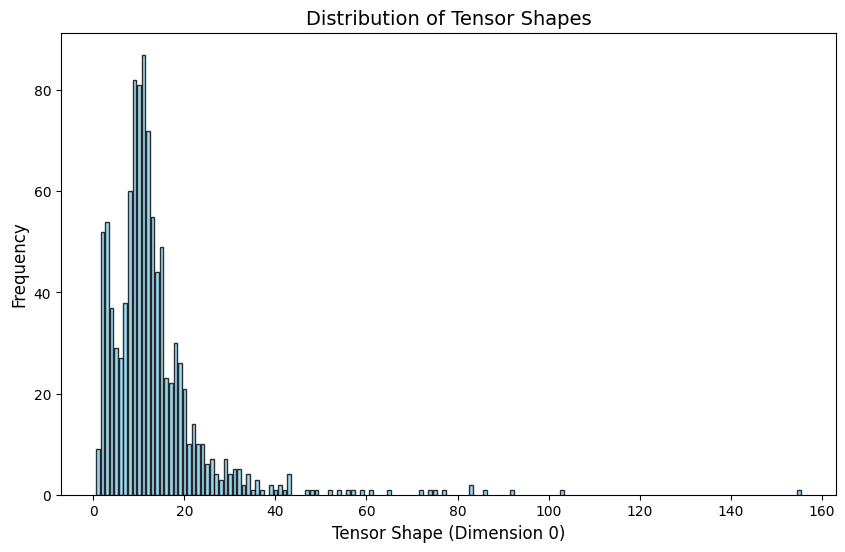

In [9]:
from collections import Counter

import matplotlib.pyplot as plt

cnt = Counter()
for e in train.iter(batch_size=64):
    for tensor in e[column_name]:
        cnt[tensor.shape[0]] += 1

shapes = sorted(cnt.keys())
frequencies = [cnt[s] for s in shapes]

# Creating the plot
plt.figure(figsize=(10, 6))
plt.bar(shapes, frequencies, color="skyblue", edgecolor="black", alpha=0.8)

plt.xlabel("Tensor Shape (Dimension 0)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Tensor Shapes", fontsize=14)

Lets have a look at the distibution of the chunk sizes. You can see that most documents are below 20 chunks, but occasionally there is a larger document, 60, 80 and even a single document with over 150 chunks.

![](img/distribution_of_chunk_size.png)

If we want to batch this, we need to pad the documents. Lets use a `FixedPadding`, such that every tensor has a shape (chunk dim) with every chunk the same size. Note this means we loose data for some documents!

Have a look at `src/vectormesh/components/padding.py` for the implementation, and study how `DynamicPadding` is different.

**question**: Which type of model architecture can handle $(batch \times chunk \times dim)$ 3D tensors where every batch has a different chunk size? And which model architecture needs a fixed chunk size every batch?


In [10]:
from vectormesh.components import FixedPadding

N=30 # set this to lower (eg 2) for the imdb dataset
padder = FixedPadding(max_chunks=N)
#  max_chunks is a hyperparameter, think about what happens when you change it 
#  or use DynamicPadding if your model architecture can handle dynamic sizes

i = 0
for batch in train.iter(batch_size=16):
    emb = padder(batch[column_name])
    print(emb.shape)
    i += 1
    if i == 2:
        break

torch.Size([16, 30, 768])
torch.Size([16, 30, 768])


```
torch.Size([16, 30, 768])
torch.Size([16, 30, 768])
```

Every batch now has an equal amount of chunks 

There are models that handle 3D tensors well. 
However, we can also aggregate the 3D tensors an turn them into 2D tensors; see `vectormesh.components.aggregation` for a few examplea few examples. Lets just use the simplest, a masked mean aggregation over the chunk dimension. The masked part is such that the padded chunks in smaller documents are ignored and don't contribute to the mean.

In [11]:
from vectormesh.components import MaskedMeanAggregator

aggregator = MaskedMeanAggregator()
padder = FixedPadding(max_chunks=N)
for batch in train.iter(batch_size=16):
    emb = padder(batch[column_name])
    agg = aggregator(emb)
    print(agg.shape)
    break

torch.Size([16, 768])


We can wrap this `MaskedMeanAggregator` in a `Serial` pipeline. This will process the components sequentially. 
Because we have just one component, this is exactly the same as just using the `MaskedMeanAggregator` directly.

In [12]:
from vectormesh.components import Serial

pipeline = Serial([MaskedMeanAggregator()])

In [13]:
padder = FixedPadding(max_chunks=N)
for batch in train.iter(batch_size=16):
    emb = padder(batch[column_name])
    output = pipeline(emb)
    print(output.shape)
    break

torch.Size([16, 768])


But the advantage of `Serial` is that we can easily add more components.

In [14]:
embed_model = list(traincache.metadata.keys())[0]
hidden_size = traincache.metadata[embed_model]['hidden_size']
print(f"Embedding model used to vectorize: {embed_model}")
print(f"Hidden size of the embeddings: {hidden_size}")

Embedding model used to vectorize: legal_dutch
Hidden size of the embeddings: 768


In [ ]:
from vectormesh.components import NeuralNet

n_classes = 32 # for imdb, use 2

pipeline = Serial([MaskedMeanAggregator(), NeuralNet(hidden_size=hidden_size, out_size=n_classes)])

In [ ]:
padder = FixedPadding(max_chunks=N)
for batch in train.iter(batch_size=16):
    emb = padder(batch[column_name])
    output = pipeline(emb)
    print(output.shape)
    break

We want to run predictions on this output. Currently, we have a model that does:

1. Input: `(batch, chunks, dim)`
2. Aggregation over chunks `(batch, chunks, dim)` -> `(batch, dim)`
3. Feed to a Neural Network `(batch, dim)` -> `(batch, num_classes)`

We now need to make sure we have a label.
Lets turn the labels into one-hot encoded vectors:


In [ ]:
import torch
from pydantic import BaseModel


class OneHot(BaseModel):
    """
    Turns a sparse integer label into a one-hot encoded vector.
    """

    num_classes: int
    label_col: str
    target_col: str

    def __call__(self, observation):
        vec = torch.zeros(self.num_classes, dtype=torch.float32)
        vec[observation[self.label_col]] = 1.0
        return {self.target_col: vec}


onehot = OneHot(num_classes=n_classes, label_col="labels", target_col="onehot") # for imdb, use label_col="label" and num_classes=2
train_oh = train.map(onehot)
valid_oh = valid.map(onehot)

We can now see how our "labels" class is turned from a single number (eg `13`) into a one-hot encoded target vector: 

`[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]`

In [ ]:
train_oh[0]

```json
{'text': "Verklaring: Het bijgevoegde stuk is ingeschreven ten kantore van de Dienst voor ...",
 'target': tensor([579]),
 'labels': tensor([13]),
 'legal_dutch': tensor([[-0.3907, -0.1823,  0.2900,  ..., -0.0104,  0.0948, -0.2597],
         [-0.4512, -0.1192,  0.1543,  ..., -0.0223, -0.0099, -0.3265],
         ...,
         [-0.5629, -0.0476,  0.1891,  ...,  0.0109,  0.2308, -0.4208]]),
 'onehot': tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])}
```


The main issue we have left before we can start training, is how to **batch** the data into padded tensors, such that we can feed them into our pipeline and directly use `mltrainer`

In [ ]:
from typing import Callable


class Collate(BaseModel):
    """
    processes a batch of Dataset items into padded tensors
    """

    embedding_col: str
    target_col: str
    padder: Callable

    def __call__(self, batch):
        embeddings = [item[self.embedding_col] for item in batch]
        X = self.padder(embeddings)
        y = torch.stack([item[self.target_col] for item in batch]).float()
        return X, y


collate_fn = Collate(
    embedding_col=embed_model,  # this picks the "legal_dutch" column
    target_col="onehot",
    padder=FixedPadding(max_chunks=N),
)

This `Collate` function will:
- get a batch
- extract the embeddings
- padd the embeddings into an input `X`
- stack the one hot encoded targets into an output `y`

We can now connect the `collate_fn` to the `DataLoader`, and we will get batches tensors.

In [ ]:
from torch.utils.data import DataLoader

trainloader = DataLoader(train_oh, batch_size=32, shuffle=True, collate_fn=collate_fn)
validloader = DataLoader(valid_oh, batch_size=32, shuffle=False, collate_fn=collate_fn)

Let us check the shapes of the tensors

In [ ]:
X, y = next(iter(trainloader))
X.shape, y.shape

We can see:

- a 3D tensor `(batch x chunks x dim)` as input: `(torch.Size([32, 30, 768])`
- a 2D tensor `(batch x onehot)` as output: `torch.Size([32, 32]))`

We now have everything prepared to start training.

In [ ]:
from pathlib import Path

from mltrainer import ReportTypes, TrainerSettings

from vectormesh.components.metrics import F1Score

log_dir = Path("demo").absolute()

settings = TrainerSettings(
    epochs=3,
    metrics=[F1Score()],
    logdir=log_dir,
    train_steps=len(trainloader),
    valid_steps=len(validloader),
    reporttypes=[ReportTypes.TENSORBOARD, ReportTypes.TOML],
)
settings

We have multilabels, so we use Binary Cross Entropy as loss function

In [ ]:
loss_fn = torch.nn.BCEWithLogitsLoss()

In [ ]:
import torch.optim as optim
from mltrainer import Trainer

from vectormesh.data.vectorizers import detect_device

device = detect_device()
print(f"Using device: {device}")

trainer = Trainer(
    model=pipeline,
    settings=settings,
    loss_fn=loss_fn,
    optimizer=optim.Adam,
    traindataloader=trainloader,
    validdataloader=validloader,
    scheduler=optim.lr_scheduler.ReduceLROnPlateau,
    device=device,
)

In [ ]:
trainer.loop()